In [1]:
import h5py
import pandas as pd

In [7]:
f = h5py.File('GW170817_GWTC-1.hdf5', 'r')
path = 'GW170817_GWTC-1.hdf5'
print(list(f.keys()))
print(type(f['IMRPhenomPv2NRT_highSpin_posterior']))
#print(type(f['Overall_posterior']))
#print(type(f['SEOBNRv3_posterior']))
#print(type(f['prior']))
post = f['IMRPhenomPv2NRT_highSpin_posterior']
print(post.dtype)

df = pd.read_hdf('GW170817_GWTC-1.hdf5', key='IMRPhenomPv2NRT_highSpin_posterior')
print(df.columns)
print(df.head(5))

distances = df['luminosity_distance_Mpc']
cos_iota = df['costheta_jn']

['IMRPhenomPv2NRT_highSpin_posterior', 'IMRPhenomPv2NRT_highSpin_prior', 'IMRPhenomPv2NRT_lowSpin_posterior', 'IMRPhenomPv2NRT_lowSpin_prior']
<class 'h5py._hl.dataset.Dataset'>
[('costheta_jn', '<f8'), ('luminosity_distance_Mpc', '<f8'), ('right_ascension', '<f8'), ('declination', '<f8'), ('m1_detector_frame_Msun', '<f8'), ('m2_detector_frame_Msun', '<f8'), ('lambda1', '<f8'), ('lambda2', '<f8'), ('spin1', '<f8'), ('spin2', '<f8'), ('costilt1', '<f8'), ('costilt2', '<f8')]
Index(['costheta_jn', 'luminosity_distance_Mpc', 'right_ascension',
       'declination', 'm1_detector_frame_Msun', 'm2_detector_frame_Msun',
       'lambda1', 'lambda2', 'spin1', 'spin2', 'costilt1', 'costilt2'],
      dtype='str')
   costheta_jn  luminosity_distance_Mpc  right_ascension  declination  \
0    -0.994916                45.252574          3.44616    -0.408084   
1    -0.986352                45.872286          3.44616    -0.408084   
2    -0.805300                37.419041          3.44616    -0.408084

In [16]:
import numpy as np
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt

In [35]:
z = 0.009877        # redshift from https://ned.ipac.caltech.edu/byname?objname=ngc+4993&hconst=67.8&omegam=0.308&omegav=0.692&wmap=4&corr_z=1
# z_uncert = 1.67e-5 do we need to take this into account?

c = 299792.458      # speed of light in km/s from https://physics.nist.gov/cgi-bin/cuu/Value?c

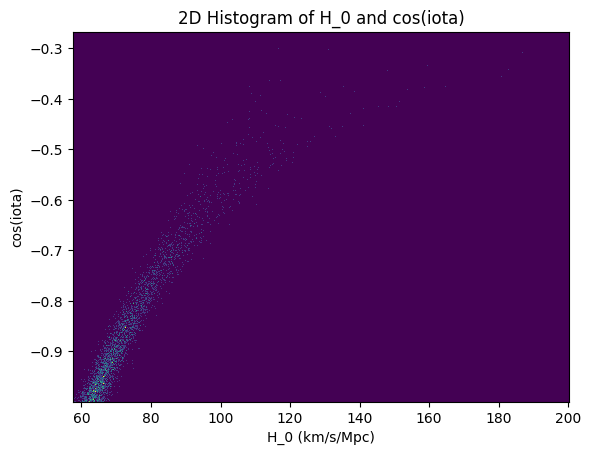

In [34]:
# low redshift approximation: d_L = (c/H_0) * z
H_0 = (c * z) / distances

#Visualize the 2D distribution of H_0 and cos(iota)
plt.hist2d(H_0, cos_iota, bins=500, range=None, density=False, weights=None, cmin=None, cmax=None, data=None)
plt.xlabel('H_0 (km/s/Mpc)')
plt.ylabel('cos(iota)')
plt.title('2D Histogram of H_0 and cos(iota)')
plt.show()

#### Computation of Jacobian:
$J = \frac{\partial d_L}{\partial H_0} = -\frac{cz}{H_0^2}$,

where we have used the low redshift approximation $d_L = \frac{cz}{H_0}$

In [41]:
# kde for 2D takes a 2D array of shape (# dims, # data)
data_l_d_cos_iota = np.vstack((distances,cos_iota))

# kde model
kde = gaussian_kde(data_l_d_cos_iota)
def likelihood (distances, cos_iota, z):
    """ 
    Compute the likelihood of the data given the model parameters (H_0, cos(iota)) using a kernel density estimate (kde) of the data.
    Makes use of the low redshift approximation to relate the luminosity distance to H_0 and the redshift.
    """

    # meshgrids used for evaluating the kde on a grid of points
    # cos iota from -1 to 1, H_0 from min to max of the samples
    H_0_grid, cos_iota_grid = np.meshgrid(np.linspace(min(H_0), max(H_0), 100), np.linspace(-1, 1, 100)) 
    # low redshift approximation: d_L = (c/H_0) * z
    d_l_grid = (c * z) / H_0_grid

    # apply kde to the grid points
    # we need to ravel the grid points and stack them into a 2D array of shape (# dims, # grid points) for the kde
    kde_values = kde(np.vstack([d_l_grid.ravel(), cos_iota_grid.ravel()]))

    # define jacobian for the transformation from (d_L, cos(iota)) to (H_0, cos(iota))
    J = (c * z) / (H_0_grid**2)

    # likelihood, need to reshape the kde values back to the shape of the grid and multiply by the jacobian
    likelihood = kde_values.reshape(H_0_grid.shape) * J

    return likelihood

likelihood_values = likelihood(distances, cos_iota, z)
#print(likelihood_values)